In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np 
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve
import joblib
import warnings
warnings.filterwarnings("ignore")

In [8]:
x_train = pd.read_csv("../data/x_train.csv")
x_test  = pd.read_csv("../data/x_test.csv")
y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/y_test.csv").squeeze()
X_full = pd.concat([x_train, x_test], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

print(f"Full dataset: {X_full.shape[0]:,} rows x {X_full.shape[1]} columns")
print(f"Class distribution:")
print(y_full.value_counts())

Full dataset: 203,101 rows x 21 columns
Class distribution:
SeriousDlqin2yrs
0    111906
1     91195
Name: count, dtype: int64


In [9]:
rf_model  = joblib.load("../models/random_forest_model.pkl")
xgb_model = joblib.load("../models/xgboost_model.pkl")
print(f"Random Forest : {rf_model}")
print(f"XGBoost       : {xgb_model}")

Random Forest : RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)
XGBoost       : XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)


In [10]:
print("Running 5-fold CV on Random Forest...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_scores = cross_val_score(
    rf_model,
    X_full,
    y_full,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)
print(f"  Scores per fold : {[round(s, 4) for s in rf_cv_scores]}")
print(f"  Mean AUC        : {rf_cv_scores.mean():.4f}")
print(f"  Std deviation   : {rf_cv_scores.std():.4f}")
print(f"  Final score     : {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

Running 5-fold CV on Random Forest...
  Scores per fold : [np.float64(0.9636), np.float64(0.9641), np.float64(0.9639), np.float64(0.9638), np.float64(0.9628)]
  Mean AUC        : 0.9636
  Std deviation   : 0.0004
  Final score     : 0.9636 ± 0.0004


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv_scores = cross_val_score(
    xgb_model,
    X_full,
    y_full,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)
print(f"  Scores per fold : {[round(s, 4) for s in xgb_cv_scores]}")
print(f"  Mean AUC        : {xgb_cv_scores.mean():.4f}")
print(f"  Std deviation   : {xgb_cv_scores.std():.4f}")
print(f"  Final score     : {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")

  Scores per fold : [np.float64(0.9784), np.float64(0.9793), np.float64(0.9786), np.float64(0.9786), np.float64(0.9776)]
  Mean AUC        : 0.9785
  Std deviation   : 0.0005
  Final score     : 0.9785 ± 0.0005


In [16]:
comparison = pd.DataFrame([
    {
        "Model"         : "Random Forest",
        "Fold 1"        : round(rf_cv_scores[0], 4),
        "Fold 2"        : round(rf_cv_scores[1], 4),
        "Fold 3"        : round(rf_cv_scores[2], 4),
        "Fold 4"        : round(rf_cv_scores[3], 4),
        "Fold 5"        : round(rf_cv_scores[4], 4),
        "Mean AUC"      : round(rf_cv_scores.mean(), 4),
        "Std"           : round(rf_cv_scores.std(), 4),
    },
    {
        "Model"         : "XGBoost",
        "Fold 1"        : round(xgb_cv_scores[0], 4),
        "Fold 2"        : round(xgb_cv_scores[1], 4),
        "Fold 3"        : round(xgb_cv_scores[2], 4),
        "Fold 4"        : round(xgb_cv_scores[3], 4),
        "Fold 5"        : round(xgb_cv_scores[4], 4),
        "Mean AUC"      : round(xgb_cv_scores.mean(), 4),
        "Std"           : round(xgb_cv_scores.std(), 4),
    }
])


print(comparison.to_string(index=False))
comparison.to_csv("../outputs/cv_comparison.csv", index=False)


        Model  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean AUC    Std
Random Forest  0.9636  0.9641  0.9639  0.9638  0.9628    0.9636 0.0004
      XGBoost  0.9784  0.9793  0.9786  0.9786  0.9776    0.9785 0.0005


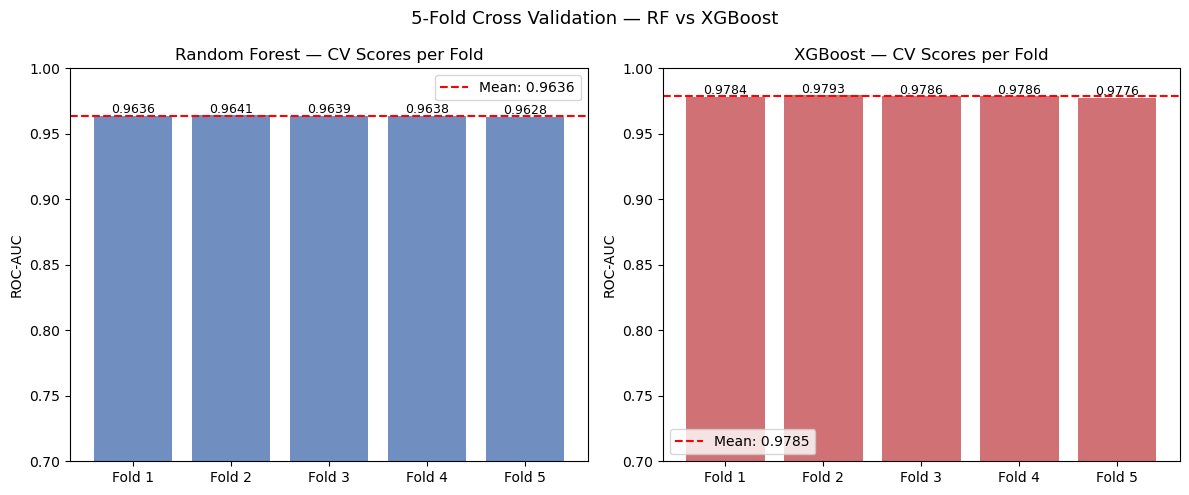

Chart saved!


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

folds = [f"Fold {i+1}" for i in range(5)]

# Random Forest
axes[0].bar(folds, rf_cv_scores, color="#4C72B0", alpha=0.8)
axes[0].axhline(y=rf_cv_scores.mean(), color="red",
                linestyle="--", label=f"Mean: {rf_cv_scores.mean():.4f}")
axes[0].set_title("Random Forest — CV Scores per Fold")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_ylim(0.7, 1.0)
axes[0].legend()
for i, v in enumerate(rf_cv_scores):
    axes[0].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

# XGBoost
axes[1].bar(folds, xgb_cv_scores, color="#C44E52", alpha=0.8)
axes[1].axhline(y=xgb_cv_scores.mean(), color="red",
                linestyle="--", label=f"Mean: {xgb_cv_scores.mean():.4f}")
axes[1].set_title("XGBoost — CV Scores per Fold")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_ylim(0.7, 1.0)
axes[1].legend()
for i, v in enumerate(xgb_cv_scores):
    axes[1].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

plt.suptitle("5-Fold Cross Validation — RF vs XGBoost", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/day8_cv_scores.png")
plt.show()
print("Chart saved!")

In [18]:
print("="*55)
print("MODEL STABILITY REPORT")
print("="*55)

print(f"\nRandom Forest:")
print(f"  Mean AUC : {rf_cv_scores.mean():.4f}")
print(f"  Std Dev  : {rf_cv_scores.std():.4f}")
if rf_cv_scores.std() < 0.01:
    print(f"  Verdict  : ✅ Very stable — consistent across all folds")
elif rf_cv_scores.std() < 0.02:
    print(f"  Verdict  : ✅ Stable — minor variation across folds")
else:
    print(f"  Verdict  : ⚠️ Unstable — high variation, check for overfitting")

print(f"\nXGBoost:")
print(f"  Mean AUC : {xgb_cv_scores.mean():.4f}")
print(f"  Std Dev  : {xgb_cv_scores.std():.4f}")
if xgb_cv_scores.std() < 0.01:
    print(f"  Verdict  : ✅ Very stable — consistent across all folds")
elif xgb_cv_scores.std() < 0.02:
    print(f"  Verdict  : ✅ Stable — minor variation across folds")
else:
    print(f"  Verdict  : ⚠️ Unstable — high variation, check for overfitting")

print(f"\nFinal recommendation:")
if rf_cv_scores.mean() > xgb_cv_scores.mean():
    print(f"  → Use Random Forest (Mean AUC: {rf_cv_scores.mean():.4f})")
else:
    print(f"  → Use XGBoost (Mean AUC: {xgb_cv_scores.mean():.4f})")

MODEL STABILITY REPORT

Random Forest:
  Mean AUC : 0.9636
  Std Dev  : 0.0004
  Verdict  : ✅ Very stable — consistent across all folds

XGBoost:
  Mean AUC : 0.9785
  Std Dev  : 0.0005
  Verdict  : ✅ Very stable — consistent across all folds

Final recommendation:
  → Use XGBoost (Mean AUC: 0.9785)
